### IMEC2543 - DINAMICA DE MAQUINARIA
### [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/) Cod. 202321287
# Taller 1

In [3]:
import numpy as np
from numpy import deg2rad, rad2deg
from sympy import symbols, pi, sin, cos, lambdify, solve, linear_eq_to_matrix, simplify, acos, sqrt, rad
import sympy as sp
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, express
from scipy import optimize
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

### Nota: Todos los recursos para esta actividad se pueden encontrar en el siguiente github, hay cosas que no adjunte como imagenes adicionales y mediciones que se encuentran aquí: https://github.com/LuigiToby/IMEC2543/tree/main/talleres/taller1

# Paso -1 — Estrategia

## Metodología

1. Modelar el RR en Python  
   - FK, IK  
   - Geometría de eslabones  
   - Obstáculo equivalente a MuJoCo  

2. Analizar restricciones del problema  
   - Giro 360° horario  
   - Efector final detrás del cubo  
   - Codo por encima del cubo  

3. Definir key-points  
   - Configuración inicial  
   - Puntos intermedios  
   - Configuración final  

4. Generar trayectoria (fase libre)  
   - Interpolación en joint space  
   - Perfiles suaves  

5. Planificación con restricción  
   - FK para evaluar posiciones  
   - Chequeo de colisión de eslabones  
   - Ajuste de trayectoria sin colisiones  

6. Construir trayectoria completa  
   - Unir fases  
   - Verificar continuidad y validez  

7. Exportar a MuJoCo  
   - Definir $q_1(t)$, $q_2(t)$)  
   - Ejecutar con PID  

8. Validación  
   - Sin colisiones  
   - Movimiento completo correcto  

# Paso 0 - Crear robot RR
Este robot ya fue un bono de clase, entonces lo reciclo de este bono

In [4]:
# Simbolos
AB, BC, CD= symbols('AB, BC, CD') 
# Simbolos dinámicos
theta1, theta2 = dynamicsymbols('theta1 theta2')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta1, N.z])
B = A.orientnew('B', 'Axis', [theta2, N.z])

params={AB:0.7,BC:0.7}

radiol1 = 0.025
radiol2 = 0.022

obs_center = (0.5, 0.2)
obs_half = (0.10, 0.10)

x_min, x_max = 0.4, 0.6
y_min, y_max = 0.1, 0.3

r1 = AB*A.x
r2 = BC*B.x

eqLoop = r1+r2

eqParams = eqLoop.subs(params)

eq_fun = lambdify(
    [theta1, theta2],
    [eqParams.dot(N.x), eqParams.dot(N.y)]
)

display(eqLoop)
display(eqParams)
display([eqParams.dot(N.x), eqParams.dot(N.y)])

AB*A.x + BC*B.x

0.7*A.x + 0.7*B.x

[-0.7*sin(theta1(t))*sin(theta2(t)) + 0.7*cos(theta1(t))*cos(theta2(t)) + 0.7*cos(theta1(t)),
 0.7*sin(theta1(t))*cos(theta2(t)) + 0.7*sin(theta1(t)) + 0.7*sin(theta2(t))*cos(theta1(t))]

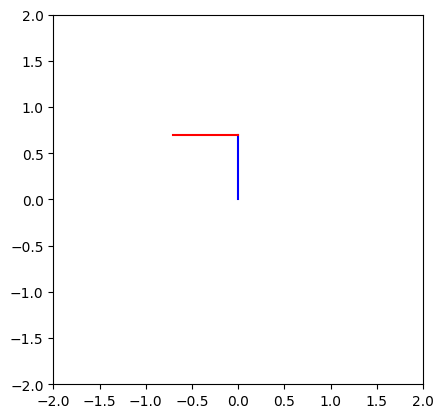

In [5]:
points={'A':0*N.x,'B':r1,'C':r1+r2}
points_fun={k:lambdify([theta1,theta2],[v.dot(N.x).subs(params),v.dot(N.y).subs(params)]) for k,v in points.items()}
# Esta función de aquí se ve complicada, pero en realidad es bastante bonita, entonces esta función
# se encarga de crear un diccionario de funciones numéricas para cada punto del mecanismo
# Cada función recibe los ángulos y la posición x de OR y devuelve las coordenadas x e y del punto correspondiente

def plotMechanism(joint_values,ax=None):    
    A=points_fun['A'](*joint_values) # Operador de unpacking, es decir, toma la lista de joint_values y los pasa como argumentos a la función de cada punto
    B=points_fun['B'](*joint_values)
    C=points_fun['C'](*joint_values)
    if ax is None:
        ax=plt.figure().add_subplot(111)
    ax.plot([A[0],B[0]], [A[1],B[1]], 'BLUE')
    ax.plot([B[0],C[0]], [B[1],C[1]], 'red')
    ax.set_aspect('equal')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)

# Example with some arbitrary joint values

plotMechanism([np.deg2rad(90),np.deg2rad(90)])

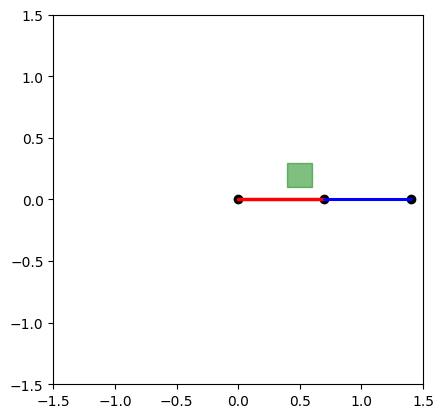

In [6]:
def plotMechanism2(joint_values, ax=None):
    A = np.array(points_fun['A'](*joint_values))
    B = np.array(points_fun['B'](*joint_values))
    C = np.array(points_fun['C'](*joint_values))

    if ax is None:
        fig, ax = plt.subplots()

    # --- LINK 1 ---
    ax.plot(
        [A[0], B[0]],
        [A[1], B[1]],
        linewidth=radiol1 * 100,   # escala visual
        color='red',
        solid_capstyle='round'
    )

    # --- LINK 2 ---
    ax.plot(
        [B[0], C[0]],
        [B[1], C[1]],
        linewidth=radiol2 * 100,
        color='blue',
        solid_capstyle='round'
    )

    # --- OBSTÁCULO ---
    rect = Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        color='green',
        alpha=0.5
    )
    ax.add_patch(rect)

    # --- JOINTS ---
    ax.scatter(A[0], A[1], color='black')
    ax.scatter(B[0], B[1], color='black')
    ax.scatter(C[0], C[1], color='black')

    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
plotMechanism2([np.deg2rad(0),np.deg2rad(0)])

In [7]:
def FK(q):
    return np.array(eq_fun(q[0], q[1]))

def IK_error(q, target):
    return np.square(FK(q) - target).sum()

def IK(target):
    seeds = [
        # [0, 0],
        # [-np.pi/2, 0.5],
        # [-np.pi, 0.5],
        [np.pi/2, np.pi/2]
        # [-2.5, 0.5]
    ]

    best_q = None
    best_err = np.inf

    for q0 in seeds:
        res = minimize(
            IK_error,
            args=(target,),
            x0=q0,
            method='L-BFGS-B'
        )

        err = IK_error(res.x, target)

        if err < best_err:
            best_err = err
            best_q = res.x

    return best_q, best_err

FK: [ 1.00000001e+00 -5.36473432e-09]
Error: 1.7190071181044442e-16
[-5.50799195  4.73279858]


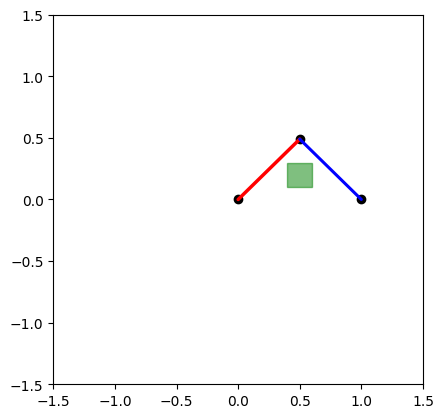

In [8]:
le_point = np.array([1,0])

qstar, err = IK(le_point)

print("FK:", FK(qstar))
print("Error:", err)
print(qstar)
plotMechanism2([qstar[0], qstar[1]])

In [9]:
import numpy as np

t = np.linspace(0, 1, 100)

traj_q = []

for s in t:
    q1 = 0 - np.pi * s      # de 0 → -π (movimiento horizontal)
    q2 = 0            # fijo (codo arriba)

    traj_q.append([q1, q2])

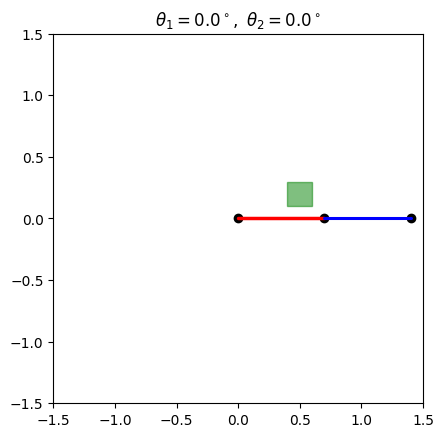

In [10]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(i):
    ax.clear()

    # trayectoria real
    q1, q2 = traj_q[i]

    joint_values = [q1, q2]

    plotMechanism2(joint_values, ax)

    ax.set_title(
        rf"$\theta_1={np.rad2deg(q1):.1f}^\circ,\ "
        rf"\theta_2={np.rad2deg(q2):.1f}^\circ$"
    )

    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(traj_q),
    interval=80,
    repeat=False,
)

HTML(anim.to_jshtml())

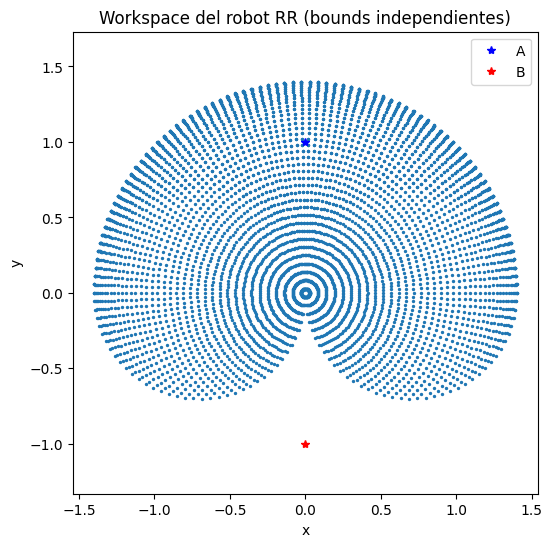

In [11]:
# Rangos independientes
theta1_vals = np.deg2rad(np.linspace(0, 180, 80))     # joint 1
theta2_vals = np.deg2rad(np.linspace(0, 360, 80))  # joint 2

# Grid en espacio de joints
th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

# almacenar posiciones del efector final
x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        q1 = th1_grid[i, j]
        q2 = th2_grid[i, j]

        C = points_fun['C'](q1, q2)
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

# plot workspace
plt.figure(figsize=(6,6))
plt.scatter(x_vals.flatten(), y_vals.flatten(), s=2)

# puntos de referencia
pos_A = [0, 1.0]
pos_B = [0, -1.0]

plt.plot(*pos_A, 'b*', label='A')
plt.plot(*pos_B, 'r*', label='B')

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace del robot RR (bounds independientes)')
plt.legend()
plt.show()

In [12]:
def segment_box_collision(P, Q, radius=0.0):
    # Inflar la caja
    x0 = x_min - radius
    x1 = x_max + radius
    y0 = y_min - radius
    y1 = y_max + radius

    # 1. Si algún punto está dentro → colisión
    if (x0 <= P[0] <= x1 and y0 <= P[1] <= y1) or \
       (x0 <= Q[0] <= x1 and y0 <= Q[1] <= y1):
        return True

    # 2. Definir función de intersección segmento-segmento
    def ccw(A, B, C):
        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])

    def intersect(A, B, C, D):
        return ccw(A,C,D) != ccw(B,C,D) and ccw(A,B,C) != ccw(A,B,D)

    # 3. Bordes del rectángulo
    rect_edges = [
        ((x0,y0),(x1,y0)),
        ((x1,y0),(x1,y1)),
        ((x1,y1),(x0,y1)),
        ((x0,y1),(x0,y0))
    ]

    # 4. Chequear intersección con cada borde
    for E1, E2 in rect_edges:
        if intersect(P, Q, E1, E2):
            return True

    return False

def checkValidity(q1, q2):
    A = np.array(points_fun['A'](q1, q2))
    B = np.array(points_fun['B'](q1, q2))
    C = np.array(points_fun['C'](q1, q2))

    if segment_box_collision(A, B, radiol1):
        return False

    if segment_box_collision(B, C, radiol2):
        return False

    return True

In [13]:
# Rangos independientes
theta1_vals = np.deg2rad(np.linspace(0, 180, 100))
theta2_vals = np.deg2rad(np.linspace(0, 360, 100))

th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

# almacenar workspace
x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

# almacenar configuraciones válidas
valid_configs = []   # ← esto es lo importante
valid_x = []
valid_y = []

invalid_x = []
invalid_y = []

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        q1 = th1_grid[i, j]
        q2 = th2_grid[i, j]

        # FK
        C = points_fun['C'](q1, q2)
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

        # check colisión
        if checkValidity(q1, q2):
            valid_configs.append([q1, q2])
            valid_x.append(C[0])
            valid_y.append(C[1])
        else:
            invalid_x.append(C[0])
            invalid_y.append(C[1])

valid_configs = np.array(valid_configs)

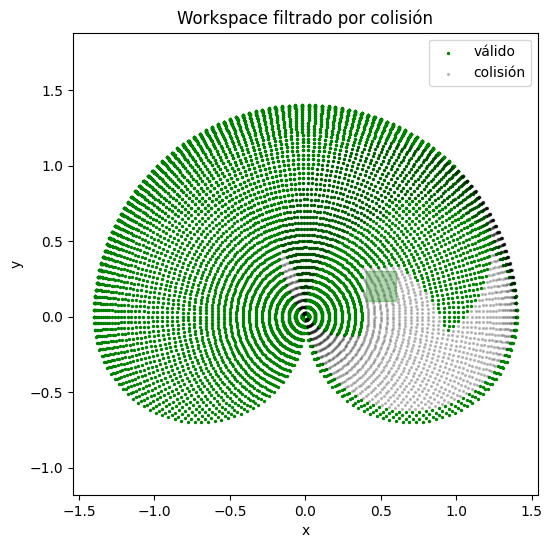

In [14]:
plt.figure(figsize=(6,6))

# válidos
plt.scatter(valid_x, valid_y, s=2, color='green', label='válido')

# inválidos
plt.scatter(invalid_x, invalid_y, s=2, color='black', alpha=0.2, label='colisión')

# obstáculo
from matplotlib.patches import Rectangle
rect = Rectangle((x_min, y_min),
                 x_max - x_min,
                 y_max - y_min,
                 color='green', alpha=0.3)
plt.gca().add_patch(rect)

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace filtrado por colisión')
plt.legend()
plt.show()

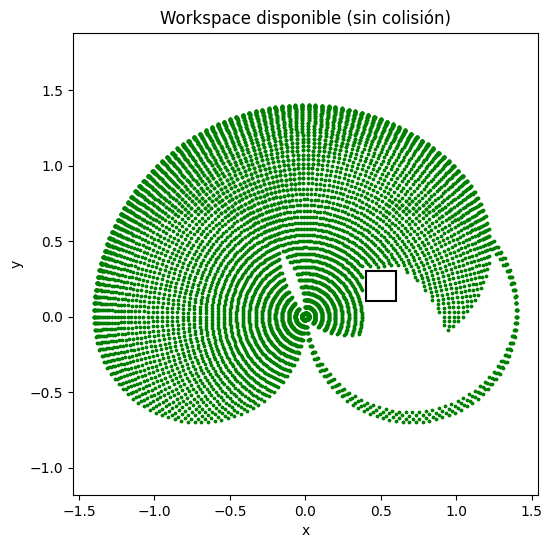

In [15]:
plt.figure(figsize=(6,6))

# SOLO puntos válidos
plt.scatter(valid_x, valid_y, s=3, color='green')

# obstáculo (solo referencia visual)
from matplotlib.patches import Rectangle
rect = Rectangle((x_min, y_min),
                 x_max - x_min,
                 y_max - y_min,
                 edgecolor='black',
                 facecolor='none',
                 linewidth=1.5)
plt.gca().add_patch(rect)

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace disponible (sin colisión)')
plt.show()

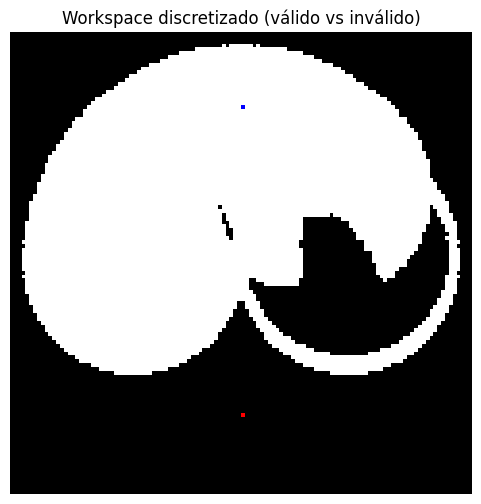

In [16]:
# --- 1. Malla cartesiana ---
delta = np.linspace(-1.5, 1.5, 120)
x_grid, y_grid = np.meshgrid(delta, delta)

# puntos válidos del workspace (ya los tienes)
pos = np.array([valid_x, valid_y])  # shape (2, N)

# --- 2. Check de validez en workspace ---
def checkValidityXY(x, y, threshold=0.001):
    # distancia al conjunto de puntos válidos
    distance2 = (pos[0] - x)**2 + (pos[1] - y)**2
    return np.min(distance2) < threshold

# --- 3. Construir mapa binario ---
valid_map = np.zeros_like(x_grid)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        valid_map[i, j] = checkValidityXY(x_grid[i,j], y_grid[i,j])

# --- 4. Puntos A y B ---
pos_A = np.array([0, 1.0])
pos_B = np.array([0, -1.0])

# mapping posición → índice
def pos_to_idx(pos):
    idx = np.floor(len(delta)*(pos - np.min(delta)) / (np.max(delta)-np.min(delta))).astype(int)
    return np.flip(idx)

idxA = pos_to_idx(pos_A)
idxB = pos_to_idx(pos_B)

# --- 5. Visualización RGB ---
visuals = np.stack([valid_map, valid_map, valid_map], axis=2)

visuals[idxA[0], idxA[1], :] = [0,0,1]  # azul
visuals[idxB[0], idxB[1], :] = [1,0,0]  # rojo

plt.figure(figsize=(6,6))
plt.imshow(np.flipud(visuals))
plt.title("Workspace discretizado (válido vs inválido)")
plt.axis('off')
plt.show()

In [17]:
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement

# OJO: valid_map viene de tu bloque anterior (0/1 en workspace)
grid = Grid(matrix=valid_map.astype(int))

# --- posiciones en workspace ---
pos_start = np.array([-1.4, 0.0])
pos_goal  = np.array([1.0, 0.0])

# --- convertir posición → índice ---
def pos_to_idx(pos):
    idx = np.floor(len(delta)*(pos - np.min(delta)) / (np.max(delta)-np.min(delta))).astype(int)
    return np.flip(idx)

idx_start = pos_to_idx(pos_start)
idx_goal  = pos_to_idx(pos_goal)

# nodos
start = grid.node(idx_start[1], idx_start[0])
end   = grid.node(idx_goal[1],  idx_goal[0])

# A*
finder = AStarFinder(diagonal_movement=DiagonalMovement.always)
path, runs = finder.find_path(start, end, grid)

print("Path length:", len(path))

Path length: 97


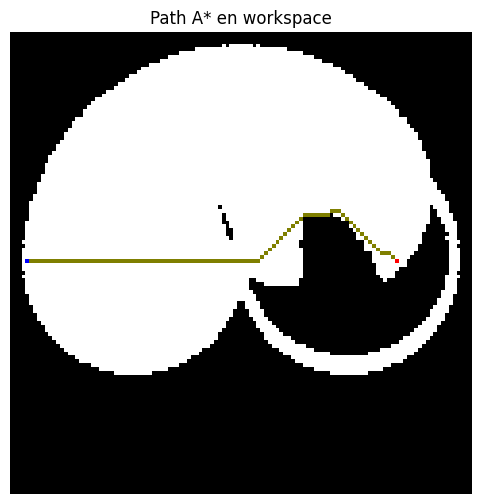

In [18]:
visuals = np.stack([valid_map, valid_map, valid_map], axis=2)

for node in path:
    visuals[node.y, node.x, :] = [0.5, 0.5, 0]  # amarillo

visuals[idx_start[0], idx_start[1], :] = [0,0,1]
visuals[idx_goal[0], idx_goal[1], :]   = [1,0,0]

plt.figure(figsize=(6,6))
plt.imshow(np.flipud(visuals))
plt.title("Path A* en workspace")
plt.axis('off')
plt.show()

In [19]:
def IK_bounds(target, q_prev):
    q_prev = np.array(q_prev).reshape(2,)

    def cost(q):
        err_pos = np.sum((FK(q) - target)**2)
        err_smooth = np.sum((q - q_prev)**2)
        return err_pos + 0.1 * err_smooth

    bounds = [
        (-2*np.pi, 2*np.pi),
        (0, 2*np.pi)
    ]

    res = minimize(
        cost,
        x0=q_prev,
        method='L-BFGS-B',
        bounds=bounds
    )

    return res.x

In [20]:
# ─────────────────────────────────────────────
#  PATH → IK → ANIMACIÓN
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.interpolate import interp1d

# --- 1. path → (x,y) ---
path_xy = np.array([
    [delta[node.x], delta[node.y]] for node in path
])

In [21]:
from scipy.optimize import minimize
import numpy as np

def FK(q):
    return np.array(eq_fun(q[0], q[1]))

def IK_error(q, target):
    return np.square(FK(q) - target).sum()

def IK(target, q_prev):
    q_prev = np.array(q_prev).reshape(2,)   # seguridad

    # bounds:
    # q1 ≥ 0
    # q2 libre
    bounds = [
        (0, None),        # q1 ∈ [0, +∞)
        (None, None)      # q2 sin restricción
    ]

    res = minimize(
        IK_error,
        args=(target,),
        x0=q_prev,
        method='L-BFGS-B',
        bounds=bounds
    )

    return res.x, IK_error(res.x, target)

In [51]:
traj_q = []

# estado inicial (muy importante)
q_prev = np.array([-np.pi, 0.0])

for x, y in path_xy:
    q, err = IK([x, y], q_prev)

    # chequeo básico
    if err > 1e-3:
        print("Mala convergencia en:", x, y)
        break

    traj_q.append(q)
    q_prev = q   # ← ESTO evita saltos

traj_q = np.array(traj_q)

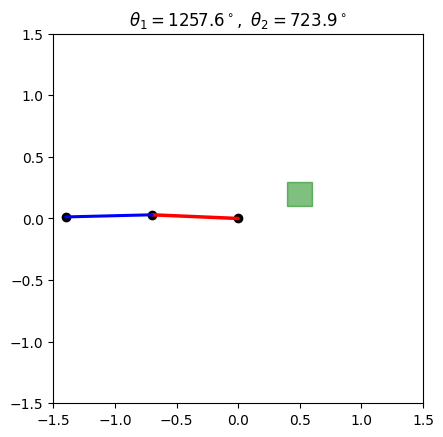

In [52]:
# --- 3. suavizado (opcional pero recomendable) ---
t_old = np.linspace(0, 1, len(traj_q))
t_new = np.linspace(0, 1, 200)

q1 = interp1d(t_old, traj_q[:,0], kind='linear')(t_new)
q2 = interp1d(t_old, traj_q[:,1], kind='linear')(t_new)

traj_q = np.vstack([q1, q2]).T

# --- 4. animación ---
fig, ax = plt.subplots()

def update(i):
    ax.clear()
    q1, q2 = traj_q[i]

    plotMechanism2([q1, q2], ax)

    ax.set_title(
        rf"$\theta_1={np.rad2deg(q1):.1f}^\circ,\ "
        rf"\theta_2={np.rad2deg(q2):.1f}^\circ$"
    )

    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(traj_q),
    interval=60,
    repeat=False,
)

HTML(anim.to_jshtml())

In [47]:
import numpy as np
from scipy.interpolate import interp1d

# ─── Parámetros de tiempo ───────────────────────────────────────
T_fase1 = 6.0   # duración de la trayectoria lineal (segundos)
T_fase2 = 6.0   # duración de la trayectoria A*     (segundos)
T_total  = T_fase1 + T_fase2

# ─── Pre-procesar traj_q (A*) una sola vez ──────────────────────
# traj_q ya viene definido de tu código A* anterior.
# Suavizado e interpolación a 200 puntos (igual que tenías):
_t_old = np.linspace(0, 1, len(traj_q))
_t_new = np.linspace(0, 1, 200)
_q1_smooth = interp1d(_t_old, traj_q[:, 0], kind='linear')(_t_new)
_q2_smooth = interp1d(_t_old, traj_q[:, 1], kind='linear')(_t_new)
_traj_suave = np.vstack([_q1_smooth, _q2_smooth]).T  # (200, 2)

# Interpoladores continuos en tiempo para la fase 2
_interp_q1 = interp1d([0.0, 1.0], [_traj_suave[0, 0],  _traj_suave[-1, 0]])
_interp_q1 = interp1d(np.linspace(0, 1, 200), _traj_suave[:, 0], kind='linear')
_interp_q2 = interp1d(np.linspace(0, 1, 200), _traj_suave[:, 1], kind='linear')


# ─── Función trayectoria(t) ─────────────────────────────────────
def trayectoria(t):
    t = np.clip(t, 0.0, T_total)

    if t <= T_fase1:
        # ── Fase 1: trayectoria lineal ──────────────────────────
        s    = t / T_fase1            # [0, 1]
        q1_d = np.pi * s
        q2_d = 0.0
    else:
        # ── Fase 2: trayectoria A* ──────────────────────────────
        s    = (t - T_fase1) / T_fase2   # [0, 1]
        s    = np.clip(s, 0.0, 1.0)
        q1_d = float(_interp_q1(s))
        q2_d = float(_interp_q2(s))

    return q1_d, q2_d

In [ ]:
def trayectoria(t):
    T_total = 6.0  # duración total

    if t > T_total:
        t = T_total

    s = t / T_total  # normalizado [0,1]

    q1_d = np.pi * s
    q2_d = 0   # pequeño ángulo para evitar singularidad

    return q1_d, q2_d

In [48]:
import mujoco
import mujoco.viewer
import numpy as np
import time
 
XML = r"""
<mujoco model="robot_RR_con_obstaculo">
 
  <compiler angle="degree"/>
  <option gravity="0 0 -9.81" timestep="0.002"/>
 
  <default>
    <joint damping="1" armature="0.01"/>
    <geom contype="1" conaffinity="1" friction="0.8 0.1 0.1" condim="3"/>
  </default>
 
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>
 
  <worldbody>
    <!-- Piso invisible -->
    <geom name="floor" type="plane" material="grid" size="5 5 5" pos="0 0 -1.5"/>
    <light pos="0 0 5" directional="true" diffuse="0.9 0.9 0.9" specular="0.1 0.1 0.1" dir="0 0 -1" castshadow="true"/>
 
    <!-- Base -->
    <body name="base" pos="0 0 0.05">
      <geom name="base_geom" type="box" size="0.04 0.04 0.04" rgba="0.3 0.3 0.3 1"/>
 
      <!-- Link 1 -->
      <body name="link1" pos="0 0 0">
        <joint name="q1" type="hinge" axis="0 1 0" range="-360 360"/>
        <geom name="link1_geom"
              type="capsule"
              fromto="0 0 0 0.7 0 0.0"
              size="0.025"
              rgba="0.8 0.4 0.4 1"/>
 
        <!-- Link 2 -->
        <body name="link2" pos="0.7 0 0">
          <joint name="q2" type="hinge" axis="0 1 0" range="-360 360"/>
          <geom name="link2_geom"
                type="capsule"
                fromto="0 0 0 0.7 0 0"
                size="0.022"
                rgba="0.4 0.4 0.8 1"/>
        </body>
      </body>
    </body>
 
    <!-- Caja -->
    <body name="obstacle" pos="0.5 0 0.2">
      <geom name="box_obstacle"
            type="box"
            size="0.10 0.08 0.10"
            rgba="0.2 0.8 0.2 1"/>
    </body>
  </worldbody>
 
  <actuator>
    <!-- Motor actuators: accept raw torque commands -->
    <motor joint="q1" ctrlrange="-200 200" gear="1"/>
    <motor joint="q2" ctrlrange="-200 200" gear="1"/>
  </actuator>
 
</mujoco>
"""
 
# ─────────────────────────────────────────────
#  PID Controller
# ─────────────────────────────────────────────
class PIDController:
    """
    Discrete PID with:
      - Anti-windup clamp on the integral term
      - Derivative on measurement (not on error) to avoid derivative kick
        when the setpoint changes abruptly
    """
    def __init__(self, kp, ki, kd, dt,
                 u_min=-200.0, u_max=200.0,
                 i_min=-50.0,  i_max=50.0):
        self.kp    = kp
        self.ki    = ki
        self.kd    = kd
        self.dt    = dt
        self.u_min = u_min
        self.u_max = u_max
        self.i_min = i_min   # anti-windup limits on integral accumulator
        self.i_max = i_max
 
        self._integral    = 0.0
        self._prev_meas   = None   # for derivative-on-measurement
 
    def reset(self):
        self._integral  = 0.0
        self._prev_meas = None
 
    def compute(self, setpoint, measurement):
        error = setpoint - measurement
 
        # --- Integral with anti-windup clamp ---
        self._integral += error * self.dt
        self._integral  = np.clip(self._integral, self.i_min, self.i_max)
 
        # --- Derivative on measurement (avoids kick on setpoint step) ---
        if self._prev_meas is None:
            self._prev_meas = measurement
        d_term = -(measurement - self._prev_meas) / self.dt
        self._prev_meas = measurement
 
        u = self.kp * error + self.ki * self._integral + self.kd * d_term
        return float(np.clip(u, self.u_min, self.u_max))
 
 
# ─────────────────────────────────────────────
#  Gravity compensation (feedforward)
#  For a 2-DOF planar arm in the XZ plane:
#    τ1 = (m1*lc1 + m2*l1)*g*cos(q1) + m2*lc2*g*cos(q1+q2)
#    τ2 = m2*lc2*g*cos(q1+q2)
#  We approximate with MuJoCo's own bias forces (data.qfrc_bias).
# ─────────────────────────────────────────────
def gravity_compensation(data):
    """
    Returns the torques needed to hold the arm against gravity,
    read directly from MuJoCo's computed bias force vector.
    """
    return data.qfrc_bias[:2].copy()   # [τ_q1, τ_q2]
 
 
# ─────────────────────────────────────────────
#  Trajectory  
# ─────────────────────────────────────────────

# Definida arriba
 
# ─────────────────────────────────────────────
#  Model & initial state
# ─────────────────────────────────────────────
model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)
 
dt = model.opt.timestep   # 0.002 s
 
data.qpos[0] = 0.0
data.qpos[1] = 0.0
data.ctrl[0] = 0.0
data.ctrl[1] = 0.0
mujoco.mj_forward(model, data)
 
# ─────────────────────────────────────────────
#  PID gains  — tune these to taste
#
#  Start conservatively:
#    kp  : proportional – main tracking gain
#    ki  : integral     – eliminates steady-state error (gravity drift)
#    kd  : derivative   – damps oscillation
# ─────────────────────────────────────────────
pid1 = PIDController(kp=120.0, ki=25.0, kd=8.0,  dt=dt)
pid2 = PIDController(kp=80.0,  ki=20.0, kd=5.0,  dt=dt)
 
 
# ─────────────────────────────────────────────
#  Collision helpers (unchanged)
# ─────────────────────────────────────────────
box_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "box_obstacle")
 
def geom_name(geom_id):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)
    return name if name is not None else f"geom_{geom_id}"
 
def detect_box_contacts(model, data, box_id):
    contacts = []
    for i in range(data.ncon):
        c = data.contact[i]
        if c.geom1 == box_id or c.geom2 == box_id:
            contacts.append(
                (geom_name(c.geom1), geom_name(c.geom2), np.array(c.pos))
            )
    return contacts
 
 
# ─────────────────────────────────────────────
#  Simulation loop
# ─────────────────────────────────────────────
collision_events  = []
collision_active  = False
 
with mujoco.viewer.launch_passive(model, data) as viewer:
    start = time.time()
 
    while viewer.is_running() and time.time() - start < 200:
        with viewer.lock():
            t = data.time
 
            # 1. Desired joint angles from trajectory
            q1_d, q2_d = trayectoria(t)
 
            # 2. Current measured joint angles
            q1 = data.qpos[0]
            q2 = data.qpos[1]
 
            # 3. PID output (feedback torque)
            tau1_fb = pid1.compute(q1_d, q1)
            tau2_fb = pid2.compute(q2_d, q2)
 
            # 4. Gravity-compensation feedforward torque
            #    (this is what cancels the "falling" effect)
            tau_grav = gravity_compensation(data)
 
            # 5. Total torque command = PID feedback + gravity feedforward
            data.ctrl[0] = tau1_fb + tau_grav[0]
            data.ctrl[1] = tau2_fb + tau_grav[1]
 
            mujoco.mj_step(model, data)
 
            # 6. Collision detection & visualisation
            contacts = detect_box_contacts(model, data, box_id)
 
            if len(contacts) > 0:
                model.geom_rgba[box_id] = np.array([1.0, 0.0, 0.0, 1.0])
            else:
                model.geom_rgba[box_id] = np.array([0.2, 0.8, 0.2, 1.0])
 
            if len(contacts) > 0 and not collision_active:
                collision_active = True
                collision_events.append({
                    "time": float(t),
                    "contacts": contacts.copy()
                })
            elif len(contacts) == 0:
                collision_active = False
 
        viewer.sync()
        time.sleep(dt)
 
# ─────────────────────────────────────────────
#  Report
# ─────────────────────────────────────────────
print("\n===== COLLISION SUMMARY =====")
if not collision_events:
    print("No collision with the green box was detected.")
else:
    for k, event in enumerate(collision_events, start=1):
        print(f"\nCollision #{k} at t = {event['time']:.3f} s")
        for g1, g2, pos in event["contacts"]:
            print(f"  {g1} <-> {g2} at {pos}")


===== COLLISION SUMMARY =====

Collision #1 at t = 6.330 s
  link1_geom <-> box_obstacle at [0.40244691 0.         0.29636941]

Collision #2 at t = 6.344 s
  link1_geom <-> box_obstacle at [0.59050395 0.         0.29785681]

Collision #3 at t = 0.012 s
  link1_geom <-> box_obstacle at [0.5999842  0.         0.10036867]

Collision #4 at t = 0.102 s
  link2_geom <-> box_obstacle at [0.40132731 0.         0.11128633]

Collision #5 at t = 0.106 s
  link2_geom <-> box_obstacle at [0.41695221 0.         0.29819748]

Collision #6 at t = 0.394 s
  link1_geom <-> box_obstacle at [0.40389132 0.         0.29408082]

Collision #7 at t = 0.402 s
  link1_geom <-> box_obstacle at [0.59300232 0.         0.29531116]

Collision #8 at t = 0.012 s
  link1_geom <-> box_obstacle at [0.5999842  0.         0.10036867]

Collision #9 at t = 0.112 s
  link2_geom <-> box_obstacle at [0.4097087  0.         0.10262668]

Collision #10 at t = 0.012 s
  link1_geom <-> box_obstacle at [0.5999842  0.         0.10036867